# 1. Imports

In [2]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

print("TF versie:", tf.__version__)

TF versie: 2.21.0


# 2. Alle gesegmenteerde hoesten inladen

In [3]:
SOUNDS_DIR = "data/sounds/sounds"

X = []
wav_paths = []  # bijhouden voor later (fases)

for candidate in os.listdir(SOUNDS_DIR):
    seg_folder = os.path.join(SOUNDS_DIR, candidate, "cough_segmented")
    if not os.path.exists(seg_folder):
        continue

    for fname in os.listdir(seg_folder):
        if not fname.endswith("_processed.wav"):
            continue

        fp = os.path.join(seg_folder, fname)
        y, sr = librosa.load(fp, sr=16000)

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # normaliseren VOOR padden
        mel_min = mel_db.min()
        mel_max = mel_db.max()
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

        # dan padden
        if mel_norm.shape[1] < 128:
            pad = np.zeros((64, 128 - mel_norm.shape[1]))
            mel_norm = np.hstack([mel_norm, pad])
        else:
            mel_norm = mel_norm[:, :128]

        X.append(mel_norm)
        wav_paths.append(fp)

X = np.array(X, dtype=np.float32)[..., np.newaxis]
print("Dataset shape:", X.shape)
print("Aantal hoesten:", len(X))

c:\Users\briek\.virtualenvs\Deep_learning_project-8qJO88P_\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (13323, 64, 128, 1)
Aantal hoesten: 13323


# 3. VAE bouwen

In [4]:
latent_dim = 32

# --- ENCODER ---
input_img = layers.Input(shape=(64, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Flatten()(x)

z_mean    = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# sampling als echte Keras laag
class SamplingLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

z = SamplingLayer()([z_mean, z_log_var])

encoder = Model(input_img, [z_mean, z_log_var, z])
print("Encoder klaar")


Encoder klaar


# 4. Decoder

In [5]:
# decoder apart definiëren
latent_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(8 * 16 * 8, activation='relu')(latent_input)
x = layers.Reshape((8, 16, 8))(x)

x = layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoder = Model(latent_input, x)
print("Decoder output shape:", decoder.output_shape)

Decoder output shape: (None, 64, 128, 1)


# 5. VAE trainen

In [6]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

EPOCHS     = 100
BATCH_SIZE = 16
dataset    = tf.data.Dataset.from_tensor_slices(X).shuffle(1000).batch(BATCH_SIZE)

# early stopping variabelen
beste_loss    = np.inf
patience      = 10
geen_verbetering = 0

for epoch in range(EPOCHS):
    losses = []

    for batch in dataset:
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = encoder(batch, training=True)
            reconstructie = decoder(z, training=True)

            recon_loss = tf.reduce_mean(tf.square(batch - reconstructie)) * 64 * 128
            kl_loss    = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            totaal     = recon_loss + kl_loss

        alle_vars = encoder.trainable_variables + decoder.trainable_variables
        grads     = tape.gradient(totaal, alle_vars)
        optimizer.apply_gradients(zip(grads, alle_vars))
        losses.append(totaal.numpy())

    epoch_loss = np.mean(losses)
    print(f"Epoch {epoch+1}/{EPOCHS} — loss: {epoch_loss:.4f}")

    # early stopping check
    if epoch_loss < beste_loss:
        beste_loss       = epoch_loss
        geen_verbetering = 0
    else:
        geen_verbetering += 1
        if geen_verbetering >= patience:
            print(f"Early stopping op epoch {epoch+1}")
            break

Epoch 1/100 — loss: 68.8636
Epoch 2/100 — loss: 22.9829
Epoch 3/100 — loss: 19.9480
Epoch 4/100 — loss: 18.5972
Epoch 5/100 — loss: 17.5035
Epoch 6/100 — loss: 16.5001
Epoch 7/100 — loss: 15.8991
Epoch 8/100 — loss: 15.5361
Epoch 9/100 — loss: 15.1221
Epoch 10/100 — loss: 14.6517
Epoch 11/100 — loss: 14.4392
Epoch 12/100 — loss: 14.2054
Epoch 13/100 — loss: 14.0155
Epoch 14/100 — loss: 13.8371
Epoch 15/100 — loss: 13.7431
Epoch 16/100 — loss: 13.5290
Epoch 17/100 — loss: 13.4863
Epoch 18/100 — loss: 13.3605
Epoch 19/100 — loss: 13.3211
Epoch 20/100 — loss: 13.1998
Epoch 21/100 — loss: 13.1505
Epoch 22/100 — loss: 13.1030
Epoch 23/100 — loss: 13.0739
Epoch 24/100 — loss: 13.0049
Epoch 25/100 — loss: 12.9463
Epoch 26/100 — loss: 12.9479
Epoch 27/100 — loss: 12.8363
Epoch 28/100 — loss: 12.8037
Epoch 29/100 — loss: 12.8401
Epoch 30/100 — loss: 12.7565
Epoch 31/100 — loss: 12.7353
Epoch 32/100 — loss: 12.6868
Epoch 33/100 — loss: 12.7097
Epoch 34/100 — loss: 12.6546
Epoch 35/100 — loss: 12

# 6. Samplen uit de latent space

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


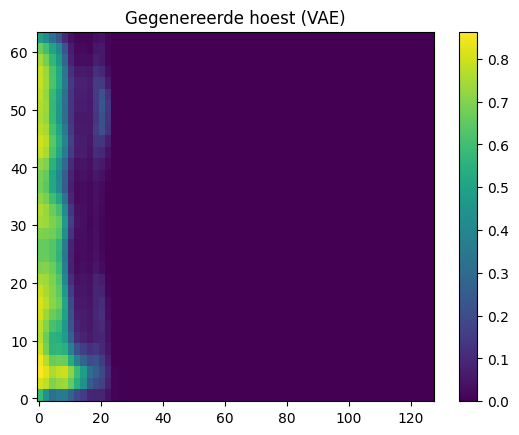

In [20]:
# sample een random punt uit de latent space
# de VAE heeft geleerd dat dit een normale verdeling is
random_z = np.random.normal(0, 1, (1, latent_dim)).astype(np.float32)

# decoderen naar mel spectrogram
gegenereerd_mel = decoder.predict(random_z)[0, :, :, 0]

plt.imshow(gegenereerd_mel, aspect='auto', origin='lower')
plt.title('Gegenereerde hoest (VAE)')
plt.colorbar()
plt.show()

# 7. Naar wav

In [21]:
# fases van een echte hoest gebruiken
echte_wav, sr = librosa.load(wav_paths[0], sr=16000)
D_orig = librosa.stft(echte_wav, n_fft=2048, hop_length=512)
fase_orig = np.angle(D_orig)

# mel terug naar wav
mel_power = librosa.db_to_power(gegenereerd_mel * 80 - 80)
mel_filters = librosa.filters.mel(sr=16000, n_fft=2048, n_mels=64)
stft_matrix = np.dot(mel_filters.T, mel_power)
stft_matrix = stft_matrix[:, :fase_orig.shape[1]]
audio = librosa.istft(stft_matrix * np.exp(1j * fase_orig), hop_length=512)
audio = audio / (np.max(np.abs(audio)) + 1e-8)

sf.write("generated/vae_cough.wav", audio, 16000)
print("Opgeslagen als generated/vae_cough.wav")

Opgeslagen als generated/vae_cough.wav
